In [64]:
from scipy import sparse
from ase.build import molecule
from ase.neighborlist import get_connectivity_matrix
from ase.neighborlist import natural_cutoffs
from ase.neighborlist import NeighborList
import ase
import numpy as np
from ase.io import read
from ase import Atoms
import ase.visualize
from ase.visualize.plot import plot_atoms
from cell2mol.read_write import readinfo
from cell2mol.cell_operations import frac2cart_fromparam, cart2frac
import nglview
from ase.build import molecule
from ase.neighborlist import NeighborList
import matplotlib.pyplot as plt

In [2]:
folder = "error_2"
name = "BOFFOS"
infopath = f"{folder}/{name}/{name}.info"
input_path = f"{folder}/{name}/{name}.cif"

In [3]:
atoms = read(input_path)
cell_labels = atoms.get_chemical_symbols()
cell_pos = atoms.positions
cell_fracs = atoms.get_scaled_positions()
cell_vector = atoms.cell.array
# cell_parameters = atoms.cell.cellpar()
space_group = atoms.info['spacegroup']
sym_ops = space_group.get_op()

/Users/ycho/miniconda3/envs/cell2mol/lib/python3.10/site-packages/ase/spacegroup/spacegroup.py:433: UserWarning: scaled_positions 0 and 59 are equivalent
  warnings.warn('scaled_positions %d and %d '
/Users/ycho/miniconda3/envs/cell2mol/lib/python3.10/site-packages/ase/spacegroup/spacegroup.py:433: UserWarning: scaled_positions 0 and 60 are equivalent
  warnings.warn('scaled_positions %d and %d '
/Users/ycho/miniconda3/envs/cell2mol/lib/python3.10/site-packages/ase/spacegroup/spacegroup.py:433: UserWarning: scaled_positions 2 and 61 are equivalent
  warnings.warn('scaled_positions %d and %d '
/Users/ycho/miniconda3/envs/cell2mol/lib/python3.10/site-packages/ase/spacegroup/spacegroup.py:433: UserWarning: scaled_positions 2 and 62 are equivalent
  warnings.warn('scaled_positions %d and %d '
/Users/ycho/miniconda3/envs/cell2mol/lib/python3.10/site-packages/ase/spacegroup/spacegroup.py:433: UserWarning: scaled_positions 3 and 63 are equivalent
  warnings.warn('scaled_positions %d and %d '


In [4]:
from cell2mol.classes import cell

labels, pos, ref_labels, ref_fracs, cellvec, cell_param = readinfo(infopath)
# labels, pos, and cellvec will not be used
ref_pos = frac2cart_fromparam(ref_fracs, cell_param)
refcell = cell.from_positional(name, ref_labels, ref_pos, ref_fracs, cell_vector, cell_param)
refcell.get_subtype("reference")
refcell.get_reference_molecules(ref_labels, ref_fracs)

#########################################
  GETREFS: Generate reference molecules  
#########################################
GETREFS: found 10 reference molecules
GETREFS: ['C6-O12-Fe', 'H24-C12-O6', 'H2-O', 'H2-O', 'H2-O', 'H24-C12-O6', 'H24-C12-O6', 'K', 'K', 'K']
GETREFS: [------------- Cell2mol MOLECULE Object --------------
 Version                      = 2.0
 Type                         = specie
 Sub-Type                     = molecule
 Number of Atoms              = 19
 Formula                      = C6-O12-Fe
 Covalent Radii Factor        = 1.3
 Metal Radii Factor           = 1.0
 Has Adjacency Matrix         = YES
 Number of Ligands            = 3
 Number of Metals             = 1
---------------------------------------------------
, ------------- Cell2mol MOLECULE Object --------------
 Version                      = 2.0
 Type                         = specie
 Sub-Type                     = molecule
 Number of Atoms              = 42
 Formula                      = H24-C12-

[------------- Cell2mol MOLECULE Object --------------
  Version                      = 2.0
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 19
  Formula                      = C6-O12-Fe
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
  Number of Ligands            = 3
  Number of Metals             = 1
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                      = 2.0
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 42
  Formula                      = H24-C12-O6
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                      = 2.0
 

In [5]:
if not refcell.has_isolated_H:  
    refcell.check_missing_H()                                     
refcell.assess_errors(ref=True)

Adjacency [8, 10, 18] ['O', 'O', 'C']
Adjacency [12, 13, 16] ['O', 'O', 'C']
Adjacency [7, 9, 17] ['O', 'O', 'C']
Adjacency [11, 14, 15] ['O', 'O', 'C']
Adjacency [1, 2, 6] ['O', 'O', 'C']
Adjacency [3, 4, 5] ['O', 'O', 'C']
Adjacency [0, 7, 8, 9] ['O', 'H', 'H', 'C']
Adjacency [1, 6, 10, 11] ['O', 'C', 'H', 'H']
Adjacency [1, 13, 14, 15] ['O', 'H', 'H', 'C']
Adjacency [2, 12, 16, 17] ['O', 'C', 'H', 'H']
Adjacency [2, 19, 20, 21] ['O', 'H', 'H', 'C']
Adjacency [3, 18, 22, 23] ['O', 'C', 'H', 'H']
Adjacency [3, 25, 26, 27] ['O', 'H', 'H', 'C']
Adjacency [4, 24, 28, 29] ['O', 'C', 'H', 'H']
Adjacency [4, 31, 32, 33] ['O', 'H', 'H', 'C']
Adjacency [5, 30, 34, 35] ['O', 'C', 'H', 'H']
Adjacency [5, 37, 38, 39] ['O', 'H', 'H', 'C']
Adjacency [0, 36, 40, 41] ['O', 'C', 'H', 'H']
Adjacency [0, 7, 8, 9] ['O', 'H', 'H', 'C']
Adjacency [1, 6, 10, 11] ['O', 'C', 'H', 'H']
Adjacency [1, 13, 14, 15] ['O', 'H', 'H', 'C']
Adjacency [2, 12, 16, 17] ['O', 'C', 'H', 'H']
Adjacency [2, 19, 20, 21] ['O',

In [6]:
for ref in refcell.refmoleclist:
    if ref.iscomplex :
        print(ref.formula, [p.subtype for p in ref.parents], [p_idx for p_idx in ref.parents_indices])
        # for met in ref.metals:
        #     print("--", met.label, [p.subtype for p in met.parents], [p_idx for p_idx in met.parents_index])
        #     # for g in met.groups:
            #     print(g.formula, [p.subtype for p in g.parents], [p_idx for p_idx in g.parents_indices])
        
        for lig in ref.ligands:
            print("--", lig.formula, lig.origin, [p.subtype for p in lig.parents], [p_idx for p_idx in lig.parents_indices])
            # for a in lig.atoms:
            #     print(a.label, [p.subtype for p in a.parents], [p_idx for p_idx in a.parents_index])
            # for g in lig.groups:
            #     print(g.formula, [p.subtype for p in g.parents], [p_idx for p_idx in g.parents_indices])
    # else :
    #     print(ref.formula, [p.subtype for p in ref.parents], [p_idx for p_idx in ref.parents_indices])
    # print("")

C6-O12-Fe ['reference'] [[1, 8, 9, 10, 11, 51, 52, 73, 74, 75, 76, 77, 78, 79, 80, 153, 154, 155, 156]]
-- C2-O4 split_complex ['molecule', 'reference'] [[8, 10, 12, 13, 16, 18], [1, 8, 9, 10, 11, 51, 52, 73, 74, 75, 76, 77, 78, 79, 80, 153, 154, 155, 156]]
-- C2-O4 split_complex ['molecule', 'reference'] [[7, 9, 11, 14, 15, 17], [1, 8, 9, 10, 11, 51, 52, 73, 74, 75, 76, 77, 78, 79, 80, 153, 154, 155, 156]]
-- C2-O4 split_complex ['molecule', 'reference'] [[1, 2, 3, 4, 5, 6], [1, 8, 9, 10, 11, 51, 52, 73, 74, 75, 76, 77, 78, 79, 80, 153, 154, 155, 156]]


In [7]:
refcell

------------- Cell2mol CELL Object ----------------
 Version               = 2.0
 Type                  = cell
 Sub-Type              = reference
 Name (Refcode)        = BOFFOS
 Num Atoms             = 157
 Cell Parameters a:c   = [24.369, 24.369, 9.748]
 Cell Parameters al:ga = [90.0, 90.0, 120.0]
---------------------------------------------------
 # of Ref Molecules:   = 10
 With Formulae:                                  
    0: C6-O12-Fe 
    1: H24-C12-O6 
    2: H2-O 
    3: H2-O 
    4: H2-O 
    5: H24-C12-O6 
    6: H24-C12-O6 
    7: K 
    8: K 
    9: K 

In [8]:
refcell.get_unique_species()

Getting unique species in cell


[------------- Cell2mol LIGAND Object --------------
  Version                      = 2.0
  Type                         = specie
  Sub-Type                     = ligand
  Number of Atoms              = 6
  Formula                      = C2-O4
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
  Origin                       = split_complex
  Number of Groups             = 2
 ---------------------------------------------------,
 ------------- Cell2mol METAL Object --------------
  Version                      = 2.0
  Type                         = atom
  Sub-Type                     = metal
  Label                        = Fe
  Atomic Number                = 26
  Index in Molecule            = 0
  Metal Adjacency (mconnec)    = 6
  Regular Adjacencies (connec) = 6
 ----------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                      = 2.0
  Type             

In [9]:
refcell.unique_species

[------------- Cell2mol LIGAND Object --------------
  Version                      = 2.0
  Type                         = specie
  Sub-Type                     = ligand
  Number of Atoms              = 6
  Formula                      = C2-O4
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
  Origin                       = split_complex
  Number of Groups             = 2
 ---------------------------------------------------,
 ------------- Cell2mol METAL Object --------------
  Version                      = 2.0
  Type                         = atom
  Sub-Type                     = metal
  Label                        = Fe
  Atomic Number                = 26
  Index in Molecule            = 0
  Metal Adjacency (mconnec)    = 6
  Regular Adjacencies (connec) = 6
 ----------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                      = 2.0
  Type             

In [10]:
refcell.unique_indices

[0, 0, 0, 1, 2, 3, 3, 3, 2, 2, 4, 4, 4]

In [13]:
debug = 2

In [66]:
from cell2mol.read_write import writexyz

In [68]:
help(writexyz)

Help on function writexyz in module cell2mol.read_write:

writexyz(fdir, fname, labels, pos, charge: int = 0, spin: int = 1)
    ##############



In [71]:
for idx, specie in enumerate(refcell.refmoleclist):
    if specie.formula == "H24-C12-O6":
        writexyz(f"{folder}/{name}", f"ref_{specie.formula}_{idx}.xyz", 
                 specie.labels, specie.coord)

In [14]:
selected_cs = []
for idx, specie in enumerate(refcell.unique_species):
    tmp = specie.get_possible_cs(debug=debug)
    if tmp is None: 
        print("error")
    if specie.subtype != "metal":
        selected_cs.append(list([cs.corr_total_charge for cs in specie.possible_cs]))
    else :
        selected_cs.append(specie.possible_cs)   

    GET_PROTONATION_STATES: Evaluating group O with parent_indices [2]
        GET_PROTONATION_STATES: evaluating non-haptic group with index 2 and label O
    GET_PROTONATION_STATES: Evaluating group O with parent_indices [1]
        GET_PROTONATION_STATES: evaluating non-haptic group with index 1 and label O
        GET_PROTONATION_STATES:protonation_states=[------------- Cell2mol Protonation ----------------
 Status                          = True
 Labels                          = ['O', 'O', 'O', 'O', 'C', 'C']
 Type                            = Local
 Atoms added in positions        = [0 0 0 0 0 0]
 Atoms blocked (no atoms added)  = [0 1 1 0 0 0]
---------------------------------------------------
]
    POSCHARGE will try charges [0, -1, 1, -2, 2, -3, 3, -4, 4]
    POSCHARGE: charge 0 with smiles [O-][C+]([O-])[C+]([O-])[O-]
    POSCHARGE: charge 0 with smiles [O-][C+]([O-])[C+]([O-])[O-]
    POSCHARGE: charge 0 with smiles [O-][C+]([O-])[C+]([O-])[O-]
    POSCHARGE: charge 0 with

In [15]:
selected_cs

[[-2], [2, 3], [0], [0], [1]]

In [16]:
from cell2mol.charge_assignment import balance_charge
final_charge_distribution, final_charges = balance_charge(refcell.unique_indices, refcell.unique_species, debug=debug)

BALANCE: iterlist [[-2], [2, 3], [0], [0], [1]]
BALANCE: unique_indices [0, 0, 0, 1, 2, 3, 3, 3, 2, 2, 4, 4, 4]
BALANCE: tmpdistr [(-2, 2, 0, 0, 1), (-2, 3, 0, 0, 1)]
BALANCE: alldistr added: [-2, -2, -2, 2, 0, 0, 0, 0, 0, 0, 1, 1, 1]
BALANCE: distribution=[-2, -2, -2, 2, 0, 0, 0, 0, 0, 0, 1, 1, 1]
BALANCE: alldistr added: [-2, -2, -2, 3, 0, 0, 0, 0, 0, 0, 1, 1, 1]
BALANCE: distribution=[-2, -2, -2, 2, 0, 0, 0, 0, 0, 0, 1, 1, 1]
BALANCE: distribution=[-2, -2, -2, 3, 0, 0, 0, 0, 0, 0, 1, 1, 1]


In [17]:
final_charge_distribution

[[-2, -2, -2, 3, 0, 0, 0, 0, 0, 0, 1, 1, 1]]

In [18]:
final_charges

[(-2, 3, 0, 0, 1)]

In [37]:
for specie, final_charge in zip(refcell.unique_species, final_charges[0]):
    print(specie.unique_index, specie.formula)
    if (specie.subtype == "molecule" and specie.iscomplex == False) or (specie.subtype == "ligand"):
        charge_list = [cs.corr_total_charge for cs in specie.possible_cs]
        idx = charge_list.index(final_charge)
        cs = specie.possible_cs[idx]
        specie.charge_state = cs
        print(specie.charge_state.protonation)
        specie.set_charges(cs.corr_total_charge, cs.corr_atom_charges, cs.smiles, cs.rdkit_obj)
    else :
        charge_list = specie.possible_cs   
        idx = charge_list.index(final_charge)
        cs = specie.possible_cs[idx]
        specie.set_charge(cs) 
    # print(specie)

0 C2-O4
------------- Cell2mol Protonation ----------------
 Status                          = True
 Labels                          = ['O', 'O', 'O', 'O', 'C', 'C']
 Type                            = Local
 Atoms added in positions        = [0 0 0 0 0 0]
 Atoms blocked (no atoms added)  = [0 1 1 0 0 0]
---------------------------------------------------

1 Fe
2 H24-C12-O6
------------- Cell2mol Protonation ----------------
 Status                          = True
 Labels                          = ['O', 'O', 'O', 'O', 'O', 'O', 'C', 'H', 'H', 'C', 'H', 'H', 'C', 'H', 'H', 'C', 'H', 'H', 'C', 'H', 'H', 'C', 'H', 'H', 'C', 'H', 'H', 'C', 'H', 'H', 'C', 'H', 'H', 'C', 'H', 'H', 'C', 'H', 'H', 'C', 'H', 'H']
 Type                            = Empty
 Atoms added in positions        = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
 Atoms blocked (no atoms added)  = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

C2-O4 canonical smiles: O=C([O-])C(=O)[O-]


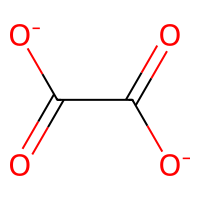

H24-C12-O6 canonical smiles: [H]C1([H])OC([H])([H])C([H])([H])OC([H])([H])C([H])([H])OC([H])([H])C([H])([H])OC([H])([H])C([H])([H])OC([H])([H])C([H])([H])OC1([H])[H]


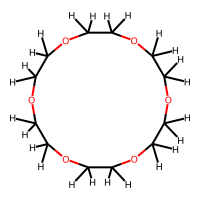

H2-O canonical smiles: [H]O[H]


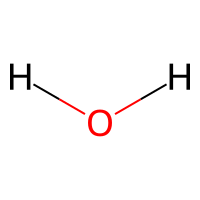

K canonical smiles: [K+]


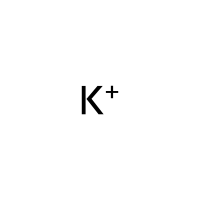

In [21]:
from IPython.display import display
from rdkit.Chem.Draw import IPythonConsole
IPythonConsole.drawOptions.addAtomIndices = False
IPythonConsole.molSize = 200,200
from rdkit import Chem
from cell2mol.connectivity import create_bonds_spicie

for specie, final_charge in zip(refcell.unique_species, final_charges[0]):
    if (specie.subtype == "molecule" and specie.iscomplex == False) or (specie.subtype == "ligand"):
        create_bonds_spicie(specie, debug=0)
        print(specie.formula, "canonical smiles:", Chem.MolToSmiles(specie.rdkit_obj, canonical=True))
        display(specie.rdkit_obj)

In [85]:
specie.rdkit_obj.

<bound method InstallIPythonRenderer.<locals>.<lambda> of <rdkit.Chem.rdchem.Mol object at 0x324028120>>

In [61]:
for ref in refcell.refmoleclist:
    print(ref)

------------- Cell2mol MOLECULE Object --------------
 Version                      = 2.0
 Type                         = specie
 Sub-Type                     = molecule
 Number of Atoms              = 19
 Formula                      = C6-O12-Fe
 Covalent Radii Factor        = 1.3
 Metal Radii Factor           = 1.0
 Has Adjacency Matrix         = YES
 Number of Ligands            = 3
 Number of Metals             = 1
---------------------------------------------------

------------- Cell2mol MOLECULE Object --------------
 Version                      = 2.0
 Type                         = specie
 Sub-Type                     = molecule
 Number of Atoms              = 42
 Formula                      = H24-C12-O6
 Covalent Radii Factor        = 1.3
 Metal Radii Factor           = 1.0
 Has Adjacency Matrix         = YES
 Total Charge                 = 0
 Smiles                       = [H]C1([H])OC([H])([H])C([H])([H])OC([H])([H])C([H])([H])OC([H])([H])C([H])([H])OC([H])([H])C([H])([H])

In [63]:
from cell2mol.connectivity import compare_species, compare_metals
from cell2mol.charge_assignment import check_rdkit_obj_connectivity, charge_state
for ref in refcell.refmoleclist:
    if hasattr(ref, "totcharge"):
        print(ref.formula, ref.totcharge)
    if ref.iscomplex:
        for lig in ref.ligands:
            for specie in refcell.unique_species:
                if specie.subtype == "ligand":
                    issame = compare_species(lig, specie)
                    set_charge_state(specie, lig)
                    # print(lig.formula, specie.formula, issame)
        for met in ref.metals:
            for specie in refcell.unique_species:
                if specie.subtype == "metal":
                    issame = compare_metals(met, specie)
                    met.set_charge(specie.charge)
                    # print(met.formula, specie.formula, issame) 
    else:
        for specie in refcell.unique_species:  
            if specie.subtype == "molecule":
                issame = compare_species(ref, specie)
                if issame:
                    set_charge_state(specie, ref)
                    print(ref.formula, specie.formula, issame)
    print("")

['O10', 'O21', 'O21', 'O10', 'C30', 'C30'] ['O10', 'O21', 'O21', 'O10', 'C30', 'C30']
len(mols)=1 received from xyz2mol with charge 1
['O10', 'O21', 'O21', 'O10', 'C30', 'C30'] ['O10', 'O21', 'O21', 'O10', 'C30', 'C30']
len(mols)=1 received from xyz2mol with charge 1
['O10', 'O21', 'O21', 'O10', 'C30', 'C30'] ['O10', 'O21', 'O21', 'O10', 'C30', 'C30']
len(mols)=1 received from xyz2mol with charge 1

H24-C12-O6 0
['O20', 'O20', 'O20', 'O20', 'O20', 'O20', 'C40', 'H10', 'H10', 'C40', 'H10', 'H10', 'C40', 'H10', 'H10', 'C40', 'H10', 'H10', 'C40', 'H10', 'H10', 'C40', 'H10', 'H10', 'C40', 'H10', 'H10', 'C40', 'H10', 'H10', 'C40', 'H10', 'H10', 'C40', 'H10', 'H10', 'C40', 'H10', 'H10', 'C40', 'H10', 'H10'] ['O20', 'O20', 'O20', 'O20', 'O20', 'O20', 'C40', 'H10', 'H10', 'C40', 'H10', 'H10', 'C40', 'H10', 'H10', 'C40', 'H10', 'H10', 'C40', 'H10', 'H10', 'C40', 'H10', 'H10', 'C40', 'H10', 'H10', 'C40', 'H10', 'H10', 'C40', 'H10', 'H10', 'C40', 'H10', 'H10', 'C40', 'H10', 'H10', 'C40', 'H10', '

In [57]:

from cell2mol.hungarian import reorder

def set_charge_state(unique_specie, target):
    
    prot = unique_specie.charge_state.protonation
    
    ref_data, target_data = arrange_data_for_reorder(unique_specie, target)
    print(ref_data, target_data)
    dummy1, dummy2, map12 = reorder(ref_data, target_data, unique_specie.coord, target.coord)
    if np.array_equal(map12, np.arange(len(target_data))):
        cs = get_charge_test(final_charge, prot)
        target.set_charges(cs.corr_total_charge, cs.corr_atom_charges, cs.smiles, cs.rdkit_obj)
    else:
        print(map12)

In [31]:
# Didn't work!!
# from rdkit.Chem import rdDetermineBonds
# for specie, final_charge in zip(refcell.unique_species, final_charges[0]):
#     if (specie.subtype == "molecule" and specie.iscomplex == False) or (specie.subtype == "ligand"):
#         print(specie, final_charge)
#         rdDetermineBonds.DetermineBondOrders(specie.rdkit_obj, charge=final_charge)

------------- Cell2mol LIGAND Object --------------
 Version                      = 2.0
 Type                         = specie
 Sub-Type                     = ligand
 Number of Atoms              = 6
 Formula                      = C2-O4
 Covalent Radii Factor        = 1.3
 Metal Radii Factor           = 1.0
 Has Adjacency Matrix         = YES
 Total Charge                 = -2
 Smiles                       = O=C([O-])C(=O)[O-]
 Origin                       = split_complex
 Number of Groups             = 2
---------------------------------------------------
 -2


ValueError: Final molecular charge does not match input; could not find valid bond ordering

In [156]:
import py3Dmol

def draw_with_spheres(mol):
    v = py3Dmol.view(width=300,height=300)
    IPythonConsole.addMolToView(mol,v)
    v.zoomTo()
    v.setStyle({'sphere':{'radius':0.3},'stick':{'radius':0.2}});
    v.show()

In [157]:
# from rdkit.Chem import rdDetermineBonds
xyzfile = "unique_specie_H24-C12-O6_2.xyz"
raw_mol = Chem.MolFromXYZFile(f"/Users/ycho/cell2mol/cell2mol/test/error_2/BOFFOS/{xyzfile}")
conn_mol = Chem.Mol(raw_mol)
rdDetermineBonds.DetermineBonds(conn_mol,charge=0)

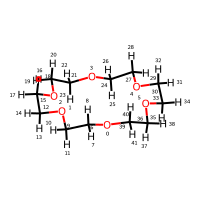

In [160]:
conn_mol

6 0 SINGLE
7 6 SINGLE
8 6 SINGLE
9 6 SINGLE
9 1 SINGLE
10 9 SINGLE
11 9 SINGLE
12 1 SINGLE
13 12 SINGLE
14 12 SINGLE
15 12 SINGLE
15 2 SINGLE
16 15 SINGLE
17 15 SINGLE
18 2 SINGLE
19 18 SINGLE
20 18 SINGLE
21 18 SINGLE
21 3 SINGLE
22 21 SINGLE
23 21 SINGLE
24 3 SINGLE
25 24 SINGLE
26 24 SINGLE
27 24 SINGLE
27 4 SINGLE
28 27 SINGLE
29 27 SINGLE
30 4 SINGLE
31 30 SINGLE
32 30 SINGLE
33 5 SINGLE
33 30 SINGLE
34 33 SINGLE
35 33 SINGLE
36 5 SINGLE
37 36 SINGLE
38 36 SINGLE
39 0 SINGLE
39 36 SINGLE
40 39 SINGLE
41 39 SINGLE


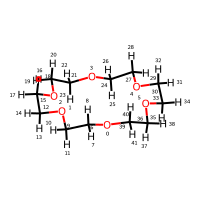

[H]C1([H])OC([H])([H])C([H])([H])OC([H])([H])C([H])([H])OC([H])([H])C([H])([H])OC([H])([H])C([H])([H])OC([H])([H])C([H])([H])OC1([H])[H]


In [162]:
from IPython.display import display
from rdkit.Chem.Draw import IPythonConsole
IPythonConsole.drawOptions.addAtomIndices = True
IPythonConsole.molSize = 200,200
for b in mol.GetBonds():
    print(b.GetBeginAtomIdx(), b.GetEndAtomIdx(), b.GetBondType())
display(mol)
smiles = Chem.MolToSmiles(mol, canonical=True)
print(smiles)

In [ ]:
def reorder_protonation (prot, map12, debug: int=0):
    if debug > 0: print("PROTONATION.REORDER. labels:", prot.labels)
    if debug > 0: print("PROTONATION.REORDER. received map:", map)

    ## for protonation states with added atoms, the reorder map will have fewer items. Correct it here 
    mapext = np.copy(map12)
    if prot.added_atoms > 0 and len(map12) < len(prot.labels):
        for ldx in range(0,prot.added_atoms):
            mapext = np.append(mapext,len(map12)+ldx)
        if debug > 0: print("PROTONATION.REORDER. extended map:", mapext)

    assert len(mapext) == len(prot.labels)
    assert len(map12)    == len(prot.addedlist)
    if len(map12) > 0:
        reordered_labels                     = [prot.labels[i] for i in mapext]
        reordered_coords                     = [prot.coords[i] for i in mapext]
        reordered_addedlist                  = [prot.addedlist[i] for i in map12]
        reordered_block                      = [prot.block[i] for i in map12]
        reordered_metal_electrons            = [prot.metal_electrons[i] for i in map12]
        reordered_elemlist                   = [prot.elemlist[i] for i in map12]


    reordered_protonation = protonation.from_positional(reordered_labels, reordered_coords, prot.cov_factor, prot.added_atoms,
                                        reordered_addedlist, reordered_block, reordered_metal_electrons, reordered_elemlist, 
                                        tmpsmiles=prot.tmpsmiles, os=prot.os, typ="Reordered", parent=prot.parent)
    print("CREATED REORDERED PROTONATION", reordered_protonation)

    return reordered_protonation

In [35]:
refcell.save(f"{folder}/{name}/Ref_Cell_{name}_NEW.cell")

SAVING cell2mol CELL object to error_2/BOFFOS/Ref_Cell_BOFFOS_NEW.cell


In [38]:
load_cell = np.load(f"{folder}/{name}/Ref_Cell_{name}_NEW.cell", allow_pickle=True)

In [55]:
for ref in load_cell.refmoleclist:
    if ref.iscomplex:
        occurrence = ref.get_occurrence(ref.ligands[0])
        print(occurrence)
        # print(ref.metals)
    #     print(ref.ligands)
    # else:
    #     print(ref)

COMPARE_SPECIES. Comparing:
C2-O4
C2-O4
COMPARE_SPECIES. kdx ldx elem1 - elem2 : reordered - reference
COMPARE_SPECIES. Comparing:
C2-O4
C2-O4
COMPARE_SPECIES. kdx ldx elem1 - elem2 : reordered - reference
COMPARE_SPECIES. Comparing:
C2-O4
C2-O4
COMPARE_SPECIES. kdx ldx elem1 - elem2 : reordered - reference
3


In [85]:
ref = refcell.refmoleclist[0]

In [90]:
spec_object = refcell.unique_species[0]

In [128]:
spec_object.possible_cs[0].protonation.atnums

[8, 8, 8, 8, 6, 6]

In [41]:
def arrange_data_for_reorder(reference: object, target: object, debug: int=0):
    # To do the reorder, we create new tags that include as much information as possible.
    # Ideally, we aim to include the label + the connectivity + the metal connectivity
    t_totconnec = 0
    t_totmconnec = 0
    for a in target.atoms:
        t_totconnec  += a.connec
        t_totmconnec += a.mconnec
    r_totconnec = 0
    r_totmconnec = 0
    for a in reference.atoms:
        r_totconnec  += a.connec
        r_totmconnec += a.mconnec
    if t_totconnec == r_totconnec:   useconec = True
    else:                            useconec = False
    if t_totmconnec == r_totmconnec: usemconec = True
    else:                            usemconec = False
    # For target
    target_data = []
    for a in target.atoms:
        data = a.label
        if useconec:  data += str(a.connec)
        if usemconec: data += str(a.mconnec)
        target_data.append(data)
    # For reference
    ref_data = []
    for a in reference.atoms:
        data = a.label
        if useconec:  data += str(a.connec)
        if usemconec: data += str(a.mconnec)
        ref_data.append(data)
    return ref_data, target_data

In [111]:
lig.get_parent_indices("molecule")

[8, 10, 12, 13, 16, 18]

In [127]:
from cell2mol.hungarian import reorder

for lig in ref.ligands:
    
    print(lig.labels, lig.get_parent_indices("molecule"))
    ref_data, target_data = arrange_data_for_reorder(spec_object, lig)
    print(ref_data, target_data)
    dummy1, dummy2, map12 = reorder(ref_data, target_data, spec_object.coord, lig.coord)
    if np.array_equal(map12, np.arange(len(target_data))):
        cs = get_charge_test(final_charge, prot)
        specie.set_charges(cs.corr_total_charge, cs.corr_atom_charges, cs.smiles, cs.rdkit_obj)
    else:
        print(map12)
    # if (map12, np.arrange(len()target_data.all():
    #     print("Yes")

['O', 'O', 'O', 'O', 'C', 'C'] [8, 10, 12, 13, 16, 18]
['O10', 'O21', 'O21', 'O10', 'C30', 'C30'] ['O10', 'O21', 'O21', 'O10', 'C30', 'C30']
['O', 'O', 'O', 'O', 'C', 'C'] [7, 9, 11, 14, 15, 17]
['O10', 'O21', 'O21', 'O10', 'C30', 'C30'] ['O10', 'O21', 'O21', 'O10', 'C30', 'C30']
['O', 'O', 'O', 'O', 'C', 'C'] [1, 2, 3, 4, 5, 6]
['O10', 'O21', 'O21', 'O10', 'C30', 'C30'] ['O10', 'O21', 'O21', 'O10', 'C30', 'C30']


In [83]:
for specie in refcell.unique_species:
    if specie.subtype != "metal":
        for cs in specie.possible_cs:
            print(cs.protonation.labels)
            print(cs.protonation.adjnum)

['O', 'O', 'O', 'O', 'C', 'C']
[1 1 1 1 3 3]
['O', 'O', 'O', 'O', 'O', 'O', 'C', 'H', 'H', 'C', 'H', 'H', 'C', 'H', 'H', 'C', 'H', 'H', 'C', 'H', 'H', 'C', 'H', 'H', 'C', 'H', 'H', 'C', 'H', 'H', 'C', 'H', 'H', 'C', 'H', 'H', 'C', 'H', 'H', 'C', 'H', 'H']
[2 2 2 2 2 2 4 1 1 4 1 1 4 1 1 4 1 1 4 1 1 4 1 1 4 1 1 4 1 1 4 1 1 4 1 1 4
 1 1 4 1 1]
['O', 'H', 'H']
[2 1 1]
['K']
[0]


In [66]:
from cell2mol.connectivity import compare_species, compare_metals
for ref in refcell.refmoleclist:
    if hasattr(ref, "totcharge"):
        print(ref.formula, ref.totcharge, ref.)
    if ref.iscomplex:
        for lig in ref.ligands:
            for specie in refcell.unique_species:
                if specie.subtype == "ligand":
                    issame = compare_species(lig, specie)
                    # print(lig.formula, specie.formula, issame)
        for met in ref.metals:
            for specie in refcell.unique_species:
                if specie.subtype == "metal":
                    issame = compare_metals(met, specie)
                    # print(met.formula, specie.formula, issame) 
    else:
        for specie in refcell.unique_species:  
            if specie.subtype == "molecule":
                issame = compare_species(ref, specie)
                if issame:
                    print(ref.formula, specie.formula, issame)
    print("")


H24-C12-O6 0
H24-C12-O6 H24-C12-O6 True

H2-O 0
H2-O H2-O True

H2-O H2-O True

H2-O H2-O True

H24-C12-O6 H24-C12-O6 True

H24-C12-O6 H24-C12-O6 True

K 1
K K True

K K True

K K True



In [14]:
from cell2mol.classes import cell
newcell = cell.from_positional(name, cell_labels, cell_pos, cell_fracs, cell_vector, cell_param)
newcell.get_subtype("unit_cell")

In [24]:
for ref in refcell.refmoleclist:
    print(ref.parents)

[------------- Cell2mol CELL Object ----------------
 Version               = 2.0
 Type                  = cell
 Sub-Type                     = reference
 Name (Refcode)        = BOFFOS
 Num Atoms             = 157
 Cell Parameters a:c   = [24.369, 24.369, 9.748]
 Cell Parameters al:ga = [90.0, 90.0, 120.0]
 Cell vector           = [[ 24.369        0.           0.        ]
 [-12.1845      21.10417306   0.        ]
 [  0.           0.           9.748     ]]
---------------------------------------------------
]
[------------- Cell2mol CELL Object ----------------
 Version               = 2.0
 Type                  = cell
 Sub-Type                     = reference
 Name (Refcode)        = BOFFOS
 Num Atoms             = 157
 Cell Parameters a:c   = [24.369, 24.369, 9.748]
 Cell Parameters al:ga = [90.0, 90.0, 120.0]
 Cell vector           = [[ 24.369        0.           0.        ]
 [-12.1845      21.10417306   0.        ]
 [  0.           0.           9.748     ]]
------------------------

In [8]:
newcell

------------- Cell2mol CELL Object ----------------
 Version               = 0.1
 Type                  = cell
 Name (Refcode)        = BOFFOS
 Num Atoms             = 525
 Cell Parameters a:c   = [24.369, 24.369, 9.748]
 Cell Parameters al:ga = [90.0, 90.0, 120.0]
 Cell vector           = [[ 24.369        0.           0.        ]
 [-12.1845      21.10417306   0.        ]
 [  0.           0.           9.748     ]]
---------------------------------------------------
 # of Ref Molecules:   = 10
 With Formulae:                                  
    0: C6-O12-Fe 
    1: H24-C12-O6 
    2: H2-O 
    3: H2-O 
    4: H2-O 
    5: H24-C12-O6 
    6: H24-C12-O6 
    7: K 
    8: K 
    9: K 

In [9]:
debug = 2

In [10]:
newcell.get_reference_molecules(ref_labels, ref_fracs, debug=0)

#########################################
  GETREFS: Generate reference molecules  
#########################################
GETREFS: found 10 reference molecules
GETREFS: ['C6-O12-Fe', 'H24-C12-O6', 'H2-O', 'H2-O', 'H2-O', 'H24-C12-O6', 'H24-C12-O6', 'K', 'K', 'K']
GETREFS: [------------- Cell2mol MOLECULE Object --------------
 Version                      = 0.1
 Type                         = specie
 Sub-Type                     = molecule
 Number of Atoms              = 19
 Formula                      = C6-O12-Fe
 Covalent Radii Factor        = 1.3
 Metal Radii Factor           = 1.0
 Has Adjacency Matrix         = YES
 Number of Ligands            = 3
 Number of Metals             = 1
---------------------------------------------------
, ------------- Cell2mol MOLECULE Object --------------
 Version                      = 0.1
 Type                         = specie
 Sub-Type                     = molecule
 Number of Atoms              = 42
 Formula                      = H24-C12-

[------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 19
  Formula                      = C6-O12-Fe
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
  Number of Ligands            = 3
  Number of Metals             = 1
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 42
  Formula                      = H24-C12-O6
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
 

In [14]:
from cell2mol.connectivity import compare_atoms, compare_species, compare_metals
debug = 2
unique_species = []
unique_indices = []

typelist_mols = [] # temporary variable  
typelist_ligs = [] # temporary variable
typelist_mets = [] # temporary variable

specs_found = -1
for idx, mol in enumerate(newcell.refmoleclist):
    if debug >= 2: print(f"Molecule {idx} formula={mol.formula}")
    if not mol.iscomplex:
        found = False
        for ldx, typ in enumerate(typelist_mols):   # Molecules
            issame = compare_species(mol, typ[0], debug=0)
            if issame :
                found = True ; kdx = typ[1]
                if debug >= 2: print(f"Molecule {idx} is the same with {ldx} in typelist")
        if not found:
            specs_found += 1 ; kdx = specs_found
            typelist_mols.append(list([mol, kdx]))
            unique_species.append(mol)
            if debug >= 2: print(f"New molecule found with: formula={mol.formula} and added in position {kdx}")
        unique_indices.append(kdx)
        mol.unique_index = kdx

    else:
        if not hasattr(mol,"ligands"): mol.split_complex(debug=debug)
        for jdx, lig in enumerate(mol.ligands):     # ligands
            found = False
            for ldx, typ in enumerate(typelist_ligs):
                issame = compare_species(lig, typ[0], debug=0)
                if issame :
                    found = True ; kdx = typ[1]
                    if debug >= 2: print(f"ligand {jdx} is the same with {ldx} in typelist")
            if not found:
                specs_found += 1 ; kdx = specs_found
                typelist_ligs.append(list([lig, kdx]))
                unique_species.append(lig)
                if debug >= 2: print(f"New ligand found with: formula {lig.formula} added in position {kdx}")
            unique_indices.append(kdx)
            lig.unique_index = kdx

        for jdx, met in enumerate(mol.metals):      #  metals
            found = False
            for ldx, typ in enumerate(typelist_mets):
                issame = compare_metals(met, typ[0], debug=0)
                if issame :
                    found = True ; kdx = typ[1]
                    if debug >= 2: print(f"Metal {jdx} is the same with {ldx} in typelist")
            if not found:
                specs_found += 1 ; kdx = specs_found
                typelist_mets.append(list([met, kdx]))
                unique_species.append(met)
                if debug >= 2: print(f"New Metal Center found with: labels {met.label} and added in position {kdx}")
            unique_indices.append(kdx)
            met.unique_index = kdx

Molecule 0 formula=C6-O12-Fe
New ligand found with: formula C2-O4 added in position 0
ligand 1 is the same with 0 in typelist
ligand 2 is the same with 0 in typelist
New Metal Center found with: labels Fe and added in position 1
Molecule 1 formula=H24-C12-O6
New molecule found with: formula=H24-C12-O6 and added in position 2
Molecule 2 formula=H2-O
New molecule found with: formula=H2-O and added in position 3
Molecule 3 formula=H2-O
Molecule 3 is the same with 1 in typelist
Molecule 4 formula=H2-O
Molecule 4 is the same with 1 in typelist
Molecule 5 formula=H24-C12-O6
Molecule 5 is the same with 0 in typelist
Molecule 6 formula=H24-C12-O6
Molecule 6 is the same with 0 in typelist
Molecule 7 formula=K
New molecule found with: formula=K and added in position 4
Molecule 8 formula=K
Molecule 8 is the same with 2 in typelist
Molecule 9 formula=K
Molecule 9 is the same with 2 in typelist


In [15]:
unique_species

[------------- Cell2mol LIGAND Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = ligand
  Number of Atoms              = 6
  Formula                      = C2-O4
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
  Origin                       = split_complex
  Number of Groups             = 2
 ---------------------------------------------------,
 ------------- Cell2mol METAL Object --------------
  Version                      = 0.1
  Type                         = atom
  Sub-Type                     = metal
  Label                        = Fe
  Atomic Number                = 26
  Index in Molecule            = 0
  Metal Adjacency (mconnec)    = 6
  Regular Adjacencies (connec) = 6
 ----------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type             

In [16]:
unique_indices

[0, 0, 0, 1, 2, 3, 3, 3, 2, 2, 4, 4, 4]

In [22]:
for ref in newcell.refmoleclist:
    if ref.iscomplex:
        for metal in ref.metals:
            print(metal.label, metal.unique_index)
        for lig in ref.ligands:
            print(lig.formula, lig.unique_index)
    else :
        print(ref.formula, ref.unique_index)

Fe 1
C2-O4 0
C2-O4 0
C2-O4 0
H24-C12-O6 2
H2-O 3
H2-O 3
H2-O 3
H24-C12-O6 2
H24-C12-O6 2
K 4
K 4
K 4


In [23]:
selected_cs = []
for idx, spec in enumerate(unique_species):
    tmp = spec.get_possible_cs(debug=debug)
    if tmp is None: 
        print("error")
        # cell.error_empty_poscharges = True
        # return # Stopping. Empty list of possible charges received. 
    if spec.subtype != "metal":
        selected_cs.append(list([cs.corr_total_charge for cs in spec.possible_cs]))
    else :
        selected_cs.append(spec.possible_cs)   
# self.error_empty_poscharges = False
print("done")

    GET_PROTONATION_STATES: Evaluating group O with parent_indices [2]
        GET_PROTONATION_STATES: evaluating non-haptic group with index 2 and label O
    GET_PROTONATION_STATES: Evaluating group O with parent_indices [1]
        GET_PROTONATION_STATES: evaluating non-haptic group with index 1 and label O
        GET_PROTONATION_STATES:protonation_states=[------------- Cell2mol Protonation ----------------
 Status                          = True
 Labels                          = ['O', 'O', 'O', 'O', 'C', 'C']
 Type                            = Local
 Atoms added in positions        = [0 0 0 0 0 0]
 Atoms blocked (no atoms added)  = [0 1 1 0 0 0]
---------------------------------------------------
]
    POSCHARGE will try charges [0, -1, 1, -2, 2, -3, 3, -4, 4]
    POSCHARGE: charge 0 with smiles [O-][C+]([O-])[C+]([O-])[O-]
    POSCHARGE: charge 0 with smiles [O-][C+]([O-])[C+]([O-])[O-]
    POSCHARGE: charge 0 with smiles [O-][C+]([O-])[C+]([O-])[O-]
    POSCHARGE: charge 0 with

In [21]:
for spec, cs in zip(unique_species, selected_cs):
    print(spec, cs)

NameError: name 'unique_species' is not defined

In [42]:
from cell2mol.charge_assignment import balance_charge
final_charge_distribution, final_charge_list = balance_charge_test(unique_indices, unique_species, debug=debug)

BALANCE: iterlist [[-2], [2, 3], [0], [0], [1]]
BALANCE: unique_indices [0, 0, 0, 1, 2, 3, 3, 3, 2, 2, 4, 4, 4]
BALANCE: tmpdistr [(-2, 2, 0, 0, 1), (-2, 3, 0, 0, 1)]
BALANCE: alldistr added: [-2, -2, -2, 2, 0, 0, 0, 0, 0, 0, 1, 1, 1]
BALANCE: distribution=[-2, -2, -2, 2, 0, 0, 0, 0, 0, 0, 1, 1, 1]

BALANCE: alldistr added: [-2, -2, -2, 3, 0, 0, 0, 0, 0, 0, 1, 1, 1]
BALANCE: distribution=[-2, -2, -2, 2, 0, 0, 0, 0, 0, 0, 1, 1, 1]
BALANCE: distribution=[-2, -2, -2, 3, 0, 0, 0, 0, 0, 0, 1, 1, 1]



In [43]:
import itertools
def balance_charge_test(unique_indices: list, unique_species: list, debug: int=0) -> list:

    # Function to Select the Best Charge Distribution for the unique species.
    # It accepts multiple charge options for each molecule/ligand/metal (poscharge, etc...).
    # NO: It should select the best one depending on whether the final metal charge makes sense or not.
    # In some cases, can accept metal oxidation state = 0, if no other makes sense

    iserror = False
    iterlist = []
    for idx, spec in enumerate(unique_species):
        toadd = []
        if spec.subtype == "metal":
            for tch in spec.possible_cs:
                toadd.append(tch)
        else :   
            if len(spec.possible_cs) == 1:
                toadd.append(spec.possible_cs[0].corr_total_charge)
            elif len(spec.possible_cs) > 1:
                for tch in spec.possible_cs:
                    toadd.append(tch.corr_total_charge)   
            elif len(spec.possible_cs) == 0:
                iserror = True
                toadd.append("-")
        iterlist.append(toadd)

    if debug >= 2: print("BALANCE: iterlist", iterlist)
    if debug >= 2: print("BALANCE: unique_indices", unique_indices)

    if not iserror:
        tmpdistr = list(itertools.product(*iterlist))
        if debug >= 2: print("BALANCE: tmpdistr", tmpdistr)

        # Expands tmpdistr to include same species, generating alldistr:
        alldistr = []
        final_selected_charges= []
        for distr in tmpdistr:
            tmp = []
            for u in unique_indices:
                tmp.append(distr[u])
            alldistr.append(tmp)
            if debug >= 2: print("BALANCE: alldistr added:", tmp)

            final_charge_distribution = []
            for idx, d in enumerate(alldistr):
                if debug >= 2: print(f"BALANCE: distribution={d}")
                final_charge = np.sum(d)
                if final_charge == 0:
                    final_charge_distribution.append(d)
                    final_selected_charges.append(distr)
            if debug >= 2: print("")
    elif iserror:
        if debug >= 1: print("Error found in BALANCE: one species has no possible charges")
        final_charge_distribution = []

    return final_charge_distribution, final_selected_charges

In [44]:
final_charge_distribution

[[-2, -2, -2, 3, 0, 0, 0, 0, 0, 0, 1, 1, 1]]

In [45]:
final_charge_list

[(-2, 3, 0, 0, 1)]

In [65]:
from IPython.display import display
from rdkit.Chem.Draw import IPythonConsole
IPythonConsole.drawOptions.addAtomIndices = True
IPythonConsole.molSize = 300,300
from rdkit import Chem
from cell2mol.connectivity import create_bonds_spicie

0
CREATE_bonds_specie: specie.formula='C2-O4', specie.subtype='ligand'
	Number of atoms in ligand object and RDKit object are equal: 6 6
	idx=0 O Number of bonds : 1
	BOND CREATED 0 0 4 2.0 O C
	BONDS [('O', 'C', 2.0, 1.219)]
	idx=1 O Number of bonds : 1
	BOND CREATED 1 1 4 1.0 O C
	BONDS [('O', 'C', 1.0, 1.28)]
	idx=2 O Number of bonds : 1
	BOND CREATED 2 2 5 2.0 O C
	BONDS [('O', 'C', 2.0, 1.273)]
	idx=3 O Number of bonds : 1
	BOND CREATED 3 3 5 1.0 O C
	BONDS [('O', 'C', 1.0, 1.213)]
	idx=4 C Number of bonds : 3
	BOND CREATED 4 4 0 2.0 C O
	BOND CREATED 4 4 1 1.0 C O
	BOND CREATED 4 4 5 1.0 C C
	BONDS [('C', 'O', 2.0, 1.219), ('C', 'O', 1.0, 1.28), ('C', 'C', 1.0, 1.554)]
	idx=5 C Number of bonds : 3
	BOND CREATED 5 5 2 2.0 C O
	BOND CREATED 5 5 3 1.0 C O
	BOND CREATED 5 5 4 1.0 C C
	BONDS [('C', 'O', 2.0, 1.273), ('C', 'O', 1.0, 1.213), ('C', 'C', 1.0, 1.554)]
------------- Cell2mol Charge State ---------------
 Status                          = True
 Smiles                        

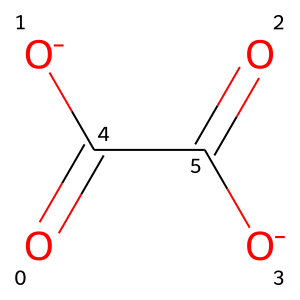

1
2
CREATE_bonds_specie: specie.formula='H24-C12-O6', specie.subtype='molecule'
	Number of atoms in molecule object and RDKit object are equal: 42 42
	idx=0 O Number of bonds : 2
	BOND CREATED 0 0 6 1.0 O C
	BOND CREATED 0 0 39 1.0 O C
	BONDS [('O', 'C', 1.0, 1.417), ('O', 'C', 1.0, 1.423)]
	idx=1 O Number of bonds : 2
	BOND CREATED 1 1 9 1.0 O C
	BOND CREATED 1 1 12 1.0 O C
	BONDS [('O', 'C', 1.0, 1.423), ('O', 'C', 1.0, 1.419)]
	idx=2 O Number of bonds : 2
	BOND CREATED 2 2 15 1.0 O C
	BOND CREATED 2 2 18 1.0 O C
	BONDS [('O', 'C', 1.0, 1.411), ('O', 'C', 1.0, 1.415)]
	idx=3 O Number of bonds : 2
	BOND CREATED 3 3 21 1.0 O C
	BOND CREATED 3 3 24 1.0 O C
	BONDS [('O', 'C', 1.0, 1.423), ('O', 'C', 1.0, 1.416)]
	idx=4 O Number of bonds : 2
	BOND CREATED 4 4 27 1.0 O C
	BOND CREATED 4 4 30 1.0 O C
	BONDS [('O', 'C', 1.0, 1.4), ('O', 'C', 1.0, 1.409)]
	idx=5 O Number of bonds : 2
	BOND CREATED 5 5 33 1.0 O C
	BOND CREATED 5 5 36 1.0 O C
	BONDS [('O', 'C', 1.0, 1.436), ('O', 'C', 1.0, 1.41

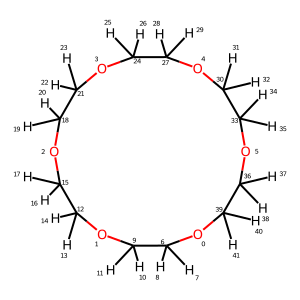

3
CREATE_bonds_specie: specie.formula='H2-O', specie.subtype='molecule'
	Number of atoms in molecule object and RDKit object are equal: 3 3
	idx=0 O Number of bonds : 2
	BOND CREATED 0 0 1 1.0 O H
	BOND CREATED 0 0 2 1.0 O H
	BONDS [('O', 'H', 1.0, 0.867), ('O', 'H', 1.0, 0.859)]
	idx=1 H Number of bonds : 1
	BOND CREATED 1 1 0 1.0 H O
	BONDS [('H', 'O', 1.0, 0.867)]
	idx=2 H Number of bonds : 1
	BOND CREATED 2 2 0 1.0 H O
	BONDS [('H', 'O', 1.0, 0.859)]
------------- Cell2mol Charge State ---------------
 Status                          = True
 Smiles                          = [H]O[H]
 Charge Tried                    = 0
 Uncorrected Total Charge        = 0
 Corrected Total Charge          = 0
 Corrected Absolute Total Charge = 0
 Corrected Is Zwitterion?        = False
---------------------------------------------------

[H]O[H]


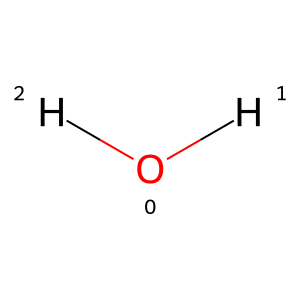

4
CREATE_bonds_specie: specie.formula='K', specie.subtype='molecule'
	Number of atoms in molecule object and RDKit object are equal: 1 1
	idx=0 K Number of bonds : 0
	NO BONDS CREATED for K due to no bonds in molecule RDKit object
------------- Cell2mol Charge State ---------------
 Status                          = True
 Smiles                          = [K+]
 Charge Tried                    = 1
 Uncorrected Total Charge        = 1
 Corrected Total Charge          = 1
 Corrected Absolute Total Charge = 1
 Corrected Is Zwitterion?        = False
---------------------------------------------------

[K+]


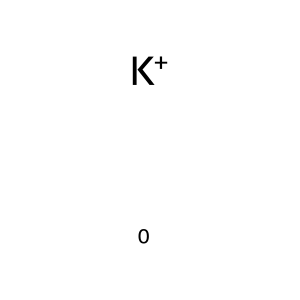

In [70]:
for specie, final_charge in zip(unique_species, final_charge_list[0]):
    print(specie.unique_index)
    if (specie.subtype == "molecule" and specie.iscomplex == False) or (specie.subtype == "ligand"):
        charge_list = [cs.corr_total_charge for cs in specie.possible_cs]
        idx = charge_list.index(final_charge)
        cs = specie.possible_cs[idx]
        specie.set_charges(cs.corr_total_charge, cs.corr_atom_charges, cs.smiles, cs.rdkit_obj)

    else :
        charge_list = specie.possible_cs   
        idx = charge_list.index(final_charge)
        cs = specie.possible_cs[idx]
        specie.set_charge(cs)     
        
    if (specie.subtype == "molecule" and specie.iscomplex == False) or (specie.subtype == "ligand"):
        create_bonds_spicie(specie, debug=2)
        print(cs)
        # print(cs.rdkit_obj)
        print(Chem.MolToSmiles(cs.rdkit_obj, canonical=True))
        display(cs.rdkit_obj)
    # print(final_charge)
    # print(spec.possible_cs)

In [ ]:
# How to match unique_specie in reference molecules to all the molecules within the unit cell?
# What is the easiest way?
for ref in newcell.refmoleclist:
    